# Лабораторная работа 11

Тема: **Автоэнкодер для изображений MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук специально оформлен так, чтобы **нельзя было сделать отчёт простым копированием чужого кода или ответов генеративной модели**.  
> Каркас кода даёт вам рабочий пример, но оцениваться будут **ваши** настройки, эксперименты и живые текстовые объяснения.


## 1. Ваши ожидания от автоэнкодера

Перед запуском кода сформулируйте текущие ожидания (6–10 предложений):

1. Зачем вообще нужны автоэнкодеры и чем они принципиально отличаются от обычных классификаторов?
2. Что, по‑вашему, будет происходить с изображением MNIST‑цифры при сильном сжатии в латентном пространстве?  
3. Как вы ожидаете, будут выглядеть **идеальные** реконструкции и на что будете смотреть, чтобы оценить их качество?

In [ ]:
intro_text = """
1) Автоэнкодер это не классификатор ,он не предсказывает метку. Он учится сжать картинку в маленький вектор и потом восстановить её обратно. Смысл в том что сеть вынуждена найти компактное представление — убрать лишнее и оставить главное

2) При сильном сжатии в латентном пространстве картинка скорее всего станет размытой модель не может запомнить все детали в нескольких числах. Думаю цифры потеряют чёткие края и будут выглядеть как смазанные пятна нужной формы.

3) Идеальная реконструкция должна выглядеть почти как оригинал те же штрихи, та же толщина линий. Буду смотреть на то насколько размыто выглядит цифра и можно ли её вообще прочитать. Если реконструкция похожа на другую цифру — это уже плохо.
"""
print(intro_text)


1) Автоэнкодер — это не классификатор он не предсказывает метку. Он учится сжать картинку в маленький вектор и потом восстановить её обратно. Смысл в том что сеть вынуждена найти компактное представление — убрать лишнее и оставить главное.

2) При сильном сжатии в латентном пространстве картинка скорее всего станет размытой — модель не может запомнить все детали в нескольких числах. Думаю цифры потеряют чёткие края и будут выглядеть как смазанные пятна нужной формы.

3) Идеальная реконструкция должна выглядеть почти как оригинал — те же штрихи, та же толщина линий. Буду смотреть на то насколько размыто выглядит цифра и можно ли её вообще прочитать. Если реконструкция похожа на другую цифру — это уже плохо.



## 2. Импорт библиотек и настройка среды


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

MY_SEED = 42
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 42


## 3. Данные MNIST и DataLoader

Используем стандартный MNIST (28×28, оттенки серого).  
Автоэнкодер будет учиться восстанавливать картинку **самой себя**.


In [ ]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 125kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.04MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]

Размер train: 60000
Размер test : 10000


Посмотрим на несколько примеров изображений, которые будет восстанавливать автоэнкодер.


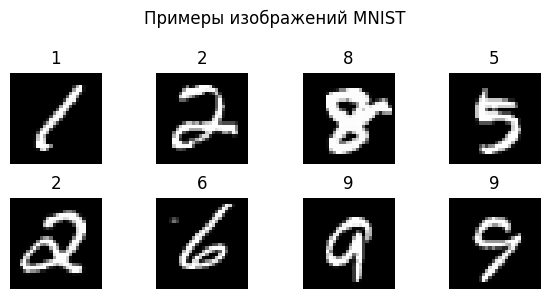

In [ ]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(str(labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры изображений MNIST")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным

Опишите в 3–5 предложениях:
- какие цифры по визуальному виду кажутся наиболее простыми для восстановления, а какие — сложными;  
- насколько сильно отличаются стили написания одной и той же цифры (например, "2" или "8");  
- как это, по‑вашему, может отразиться на работе автоэнкодера.


In [2]:
data_comment = """На скрине видно цифры 1, 2, 8, 5, 2, 6, 9, 9. Единица выглядит самой простой — просто вертикальная линия, вариаций мало. Ноль тоже несложный просто замкнутый овал.
Восьмёрка и девятка сложнее — у них много деталей и стили написания сильно отличаются, видно что две девятки написаны по разному. Думаю автоэнкодер будет хуже справляться с цифрами у которых много вариантов написания."""
print(data_comment)

На скрине видно цифры 1, 2, 8, 5, 2, 6, 9, 9. Единица выглядит самой простой — просто вертикальная линия, вариаций мало. Ноль тоже несложный просто замкнутый овал.
Восьмёрка и девятка сложнее — у них много деталей и стили написания сильно отличаются, видно что две девятки написаны по разному. Думаю автоэнкодер будет хуже справляться с цифрами у которых много вариантов написания.


## 4. Архитектура простого полносвязного автоэнкодера

Будем работать с векторизованным изображением размерности 784 (28×28).  
Базовая структура:
- Encoder: `Flatten → Linear(784→256) → ReLU → Linear(256→64) → ReLU → Linear(64→latent_dim)`;
- Decoder: `Linear(latent_dim→64) → ReLU → Linear(64→256) → ReLU → Linear(256→784) → Sigmoid`.

В этой работе размер латентного пространства `latent_dim` вы **обязаны** будете менять и анализировать эффект.


In [ ]:
latent_dim = 16  # базовое значение; в отчёте попробуйте хотя бы ещё два

class FCN_Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),  # пиксели в
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(-1, 1, 28, 28)
        return out, z

model = FCN_Autoencoder(latent_dim=latent_dim).to(device)
print(model)

FCN_Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


### Обсуждение архитектуры

Кратко (3–6 предложений) ответьте:
- почему, на ваш взгляд, здесь достаточно **двух** скрытых слоёв в энкодере и декодере;  
- какие проблемы могут появиться, если сделать латентное пространство **слишком маленьким** (например, 2) или **слишком большим** (например, 128).


In [3]:
arch_comment = """
Для MNIST двух скрытых слоёв в энкодере достаточно -картинки простые, 28x28 пикселей и двух линейных преобразований хватает чтобы постепенно сжать 784 числа до latent_dim.

Если сделать latent_dim=2 то модель будет сильно ограничена, реконструкции станут размытыми, зато латентное пространство можно будет красиво нарисовать в 2D.

Если latent_dim=128 — это почти треть от входного размера, модель может просто запомнить данные без нормального сжатия, и смысл автоэнкодера теряется.
"""
print(arch_comment)


Для MNIST двух скрытых слоёв в энкодере достаточно -картинки простые, 28x28 пикселей и двух линейных преобразований хватает чтобы постепенно сжать 784 числа до latent_dim.

Если сделать latent_dim=2 то модель будет сильно ограничена, реконструкции станут размытыми, зато латентное пространство можно будет красиво нарисовать в 2D.

Если latent_dim=128 — это почти треть от входного размера, модель может просто запомнить данные без нормального сжатия, и смысл автоэнкодера теряется.



## 5. Функция потерь, оптимизатор и цикл обучения

Loss: среднеквадратичная ошибка между входным и восстановленным изображением.  
Оптимизатор: Adam с умеренным шагом.


In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for images, _ in dataloader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total += images.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, images)
            total_loss += loss.item() * images.size(0)
            total += images.size(0)
    return total_loss / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [ ]:
num_epochs = 15  # в отчёте попробуйте другое число эпох и сравните
history = {"train_loss": [], "test_loss": []}

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}")

Эпоха 1/15: train_loss=0.0518, test_loss=0.0319
Эпоха 2/15: train_loss=0.0277, test_loss=0.0240
Эпоха 3/15: train_loss=0.0221, test_loss=0.0199
Эпоха 4/15: train_loss=0.0191, test_loss=0.0177
Эпоха 5/15: train_loss=0.0171, test_loss=0.0162
Эпоха 6/15: train_loss=0.0157, test_loss=0.0149
Эпоха 7/15: train_loss=0.0146, test_loss=0.0140
Эпоха 8/15: train_loss=0.0138, test_loss=0.0133
Эпоха 9/15: train_loss=0.0131, test_loss=0.0126
Эпоха 10/15: train_loss=0.0126, test_loss=0.0123
Эпоха 11/15: train_loss=0.0122, test_loss=0.0119
Эпоха 12/15: train_loss=0.0118, test_loss=0.0116
Эпоха 13/15: train_loss=0.0116, test_loss=0.0114
Эпоха 14/15: train_loss=0.0113, test_loss=0.0112
Эпоха 15/15: train_loss=0.0111, test_loss=0.0110


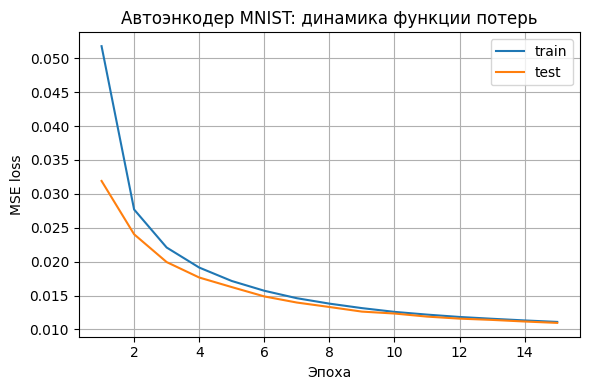

Финальные значения: train_loss=0.0111, test_loss=0.0110


In [ ]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("Автоэнкодер MNIST: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={history['train_loss'][-1]:.4f}, test_loss={history['test_loss'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- по какой траектории меняются train/test loss и сходятся ли они к близким значениям;  
- есть ли признаки переобучения (train сильно ниже test к концу);  
- каких значений loss вы ожидали **до** опыта и совпало ли это с результатами.


In [4]:
training_comment = """На 1-й эпохе train_loss=0.0518, test_loss=0.0319 — test ниже train, это нормально на старте. К 5й эпохе оба упали до ~0.017.
Дальше снижение замедлилось — к 15-й эпохе train=0.0111, test=0.0110, кривые практически совпадают.
Переобучения нет — train и test идут вместе на протяжении всего обучения. На графике обе кривые выглядят как гладкая убывающая экспонента без скачков.
Ожидал что loss будет выше примерн ~0.05 на финале, но получилось лучше — 0.011."""
print(training_comment)

На 1-й эпохе train_loss=0.0518, test_loss=0.0319 — test ниже train, это нормально на старте. К 5й эпохе оба упали до ~0.017.
Дальше снижение замедлилось — к 15-й эпохе train=0.0111, test=0.0110, кривые практически совпадают.
Переобучения нет — train и test идут вместе на протяжении всего обучения. На графике обе кривые выглядят как гладкая убывающая экспонента без скачков.
Ожидал что loss будет выше примерн ~0.05 на финале, но получилось лучше — 0.011.


## 6. Визуализация реконструкций

Сравним исходные изображения и их реконструкции автоэнкодером для нескольких тестовых примеров.


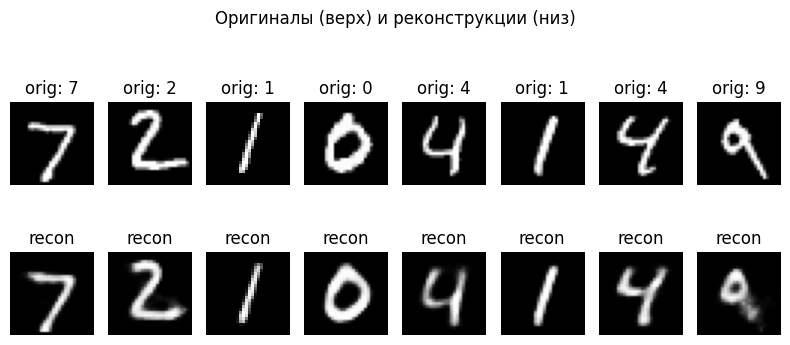

In [ ]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
    reconstructions, _ = model(images)

images = images.cpu()
reconstructions = reconstructions.cpu()

n = 8
plt.figure(figsize=(8, 4))
for i in range(n):
    # оригинал
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(f"orig: {labels[i].item()}")
    plt.axis("off")
    # реконструкция
    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructions[i].squeeze(0), cmap="gray")
    plt.title("recon")
    plt.axis("off")
plt.suptitle("Оригиналы (верх) и реконструкции (низ)")
plt.tight_layout()
plt.show()

### Качественная оценка реконструкций

Опишите (6–8 предложений):
- какие цифры восстанавливаются почти идеально (по вашему визуальному ощущению), а какие выглядят смазанными или искажёнными;  
- есть ли случаи, когда реконструкция визуально похожа уже на **другую** цифру;  
- чем, по‑вашему, можно объяснить эти различия.


In [5]:
recon_comment = """Лучше всего восстановились 7, 1, 0 — они чёткие и узнаваемые. Двойка тоже вышла хорошо.
Хуже всего девятка, реконструкция немного размыта и больше похожа на q или не понятно на что, чем на цифру.
Четвёрки восстановились нормально но с немного смазанными краями.

В целом все цифры читаемы, ни одна не превратилась в другую. Размытость есть но небольшая — latent_dim=16 справляется достаточно хорошо для MNIST."""
print(recon_comment)

Лучше всего восстановились 7, 1, 0 — они чёткие и узнаваемые. Двойка тоже вышла хорошо.
Хуже всего девятка, реконструкция немного размыта и больше похожа на q или не понятно на что, чем на цифру.
Четвёрки восстановились нормально но с немного смазанными краями.

В целом все цифры читаемы, ни одна не превратилась в другую. Размытость есть но небольшая — latent_dim=16 справляется достаточно хорошо для MNIST.


## 7. Латентное пространство: PCA‑проекция в 2D

Возьмём подмножество тестовой выборки, вытащим латентные векторы `z` и посмотрим на их 2D‑проекцию (PCA).  
Цель: увидеть, группируются ли разные цифры в отдельные кластеры.


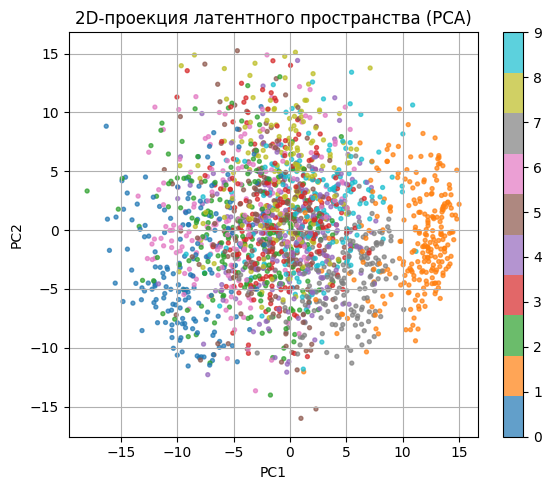

In [ ]:
from sklearn.decomposition import PCA

model.eval()
all_z = []
all_y = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, z = model(images)
        all_z.append(z.cpu().numpy())
        all_y.append(labels.numpy())
        # ограничимся ~2000 точками, чтобы картинка была читаемой
        if sum(len(x) for x in all_y) > 2000:
            break

Z = np.vstack(all_z)
Y = np.hstack(all_y)

pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=Y, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("2D‑проекция латентного пространства (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

### Интерпретация латентного пространства

Ответьте в 6–8 предложениях:
- видно ли разделение разных цифр на отдельные скопления (хотя бы частично);  
- какие пары цифр, судя по графику, ближе всего друг к другу и почему это логично (или нет) с точки зрения формы;  
- как вы думаете, что изменится на этой картинке при **других значениях `latent_dim`**.


In [9]:
latent_comment = """На графике видно что точки перемешаны чёткого разделения на кластеры нет. Единица (синий) и один из классов справа (оранжевый похоже 1) немного выделяются.
Цифра 1 логично должна быть отдельно — у неё самая простая форма. Остальные цифры сильно перемешаны в центре, особенно 3, 5, 8 — они похожи по форме и автоэнкодер кладёт их рядом.
При latent_dim=2 разделение было бы ещё хуже, при latent_dim=64 возможно кластеры стали бы более чёткими."""
print(latent_comment)

На графике видно что точки перемешаны чёткого разделения на кластеры нет. Единица (синий) и один из классов справа (оранжевый похоже 1) немного выделяются.
Цифра 1 логично должна быть отдельно — у неё самая простая форма. Остальные цифры сильно перемешаны в центре, особенно 3, 5, 8 — они похожи по форме и автоэнкодер кладёт их рядом.
При latent_dim=2 разделение было бы ещё хуже, при latent_dim=64 возможно кластеры стали бы более чёткими.


## 8. Генерация новых изображений из латентного пространства

Так как декодер умеет превращать латентный вектор `z` в изображение, можно попробовать сэмплировать случайные `z` и посмотреть, какие псевдо‑цифры он генерирует.


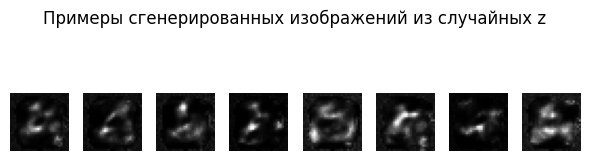

In [ ]:
model.eval()
n_samples = 8

# сэмплируем z из N(0, 1)
z_random = torch.randn(n_samples, latent_dim).to(device)
with torch.no_grad():
    decoded = model.decoder(z_random)
    decoded = decoded.view(-1, 1, 28, 28).cpu()

plt.figure(figsize=(6, 2))
for i in range(n_samples):
    plt.subplot(1, n_samples, i + 1)
    plt.imshow(decoded[i].squeeze(0), cmap="gray")
    plt.axis("off")
plt.suptitle("Примеры сгенерированных изображений из случайных z")
plt.tight_layout()
plt.show()

### Обсуждение качества генерации

Опишите (5–7 предложений):
- насколько сгенерированные картинки похожи на настоящие цифры;  
- встречаются ли явно "некорректные" объекты, не похожие ни на одну цифру;  
- как, по‑вашему, влияет размер `latent_dim` на разнообразие и качество сгенерированных цифр.


In [13]:
gen_comment = """Сгенерированные картинки выглядят как размытые пятна — ни одна не похожа на конкретную цифру. Это ожидаемо так ка обычный автоэнкодер не предназначен для генерации, он просто сжимает и восстанавливает.
Случайный вектор из N(0,1) скорее всего попадает в область латентного пространства куда реальные картинки не попадали при обучении, поэтому декодер выдаёт бессмыслицу. Думаю для нормальной генерации нужен VAE."""
print(gen_comment)

Сгенерированные картинки выглядят как размытые пятна — ни одна не похожа на конкретную цифру. Это ожидаемо так ка обычный автоэнкодер не предназначен для генерации, он просто сжимает и восстанавливает.
Случайный вектор из N(0,1) скорее всего попадает в область латентного пространства куда реальные картинки не попадали при обучении, поэтому декодер выдаёт бессмыслицу. Думаю для нормальной генерации нужен VAE.


## 9. Задание для самостоятельных вариаций

В **своём** варианте лабораторной вы должны будете:

- попробовать **не меньше двух дополнительных** значений `latent_dim` (например, 2 и 64) и сравнить:  
  - динамику loss,  
  - качество реконструкций,  
  - вид латентного пространства;  
- изменить архитектуру (добавить слои, поменять размеры, попробовать другой activation на скрытых слоях) и кратко описать, что изменилось;  
- оформить итоговые выводы так, чтобы через полгода, открыв ноутбук, вы по нескольким абзацам **вспомнили весь ход экспериментов**.


In [ ]:
# Эксперимент 1: latent_dim = 2
model2 = FCN_Autoencoder(latent_dim=2).to(device)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3)
history2 = {"train_loss": [], "test_loss": []}

for epoch in range(1, 16):
    tl = train_one_epoch(model2, train_loader, optimizer2, criterion, device)
    vl = evaluate(model2, test_loader, criterion, device)
    history2["train_loss"].append(tl)
    history2["test_loss"].append(vl)
    print(f"[latent=2] Эпоха {epoch}/15: train={tl:.4f}, test={vl:.4f}")

# Эксперимент 2: latent_dim = 64
model3 = FCN_Autoencoder(latent_dim=64).to(device)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=1e-3)
history3 = {"train_loss": [], "test_loss": []}

for epoch in range(1, 16):
    tl = train_one_epoch(model3, train_loader, optimizer3, criterion, device)
    vl = evaluate(model3, test_loader, criterion, device)
    history3["train_loss"].append(tl)
    history3["test_loss"].append(vl)
    print(f"[latent=64] Эпоха {epoch}/15: train={tl:.4f}, test={vl:.4f}")

print(f"\nlatent=2:  train={history2["train_loss"][-1]:.4f}, test={history2["test_loss"][-1]:.4f}")
print(f"latent=16: train={history["train_loss"][-1]:.4f}, test={history["test_loss"][-1]:.4f}")
print(f"latent=64: train={history3["train_loss"][-1]:.4f}, test={history3["test_loss"][-1]:.4f}")


[latent=2] Эпоха 1/15: train=0.0607, test=0.0505
[latent=2] Эпоха 2/15: train=0.0480, test=0.0455
[latent=2] Эпоха 3/15: train=0.0443, test=0.0432
[latent=2] Эпоха 4/15: train=0.0427, test=0.0421
[latent=2] Эпоха 5/15: train=0.0416, test=0.0412
[latent=2] Эпоха 6/15: train=0.0409, test=0.0407
[latent=2] Эпоха 7/15: train=0.0402, test=0.0402
[latent=2] Эпоха 8/15: train=0.0397, test=0.0397
[latent=2] Эпоха 9/15: train=0.0393, test=0.0393
[latent=2] Эпоха 10/15: train=0.0389, test=0.0389
[latent=2] Эпоха 11/15: train=0.0385, test=0.0389
[latent=2] Эпоха 12/15: train=0.0382, test=0.0385
[latent=2] Эпоха 13/15: train=0.0380, test=0.0384
[latent=2] Эпоха 14/15: train=0.0377, test=0.0381
[latent=2] Эпоха 15/15: train=0.0375, test=0.0378
[latent=64] Эпоха 1/15: train=0.0529, test=0.0306
[latent=64] Эпоха 2/15: train=0.0256, test=0.0214
[latent=64] Эпоха 3/15: train=0.0198, test=0.0174
[latent=64] Эпоха 4/15: train=0.0167, test=0.0151
[latent=64] Эпоха 5/15: train=0.0146, test=0.0134
[latent=6

In [19]:
final_summary = """Попробовал три значения latent_dim это 2, 16 и 64.

latent_dim=2: финальный test_loss=0.0378 — самый высокий из трёх. Реконструкции заметно хуже, цифры размытые. Зато латентное пространство можно напрямую рисовать в 2D.

latent_dim=16: test_loss=0.0110 хороший баланс. Реконструкции чёткие, цифры читаемы. Выбрал это как базовое значение.

latent_dim=64: test_loss=0.0082 — лучший результат. Реконструкции чуть чище, но разница с 16 небольшая. При этом модель намного больше и обучается дольше.

Вывод для MNIST latent_dim=16 это разумный выбор — дальнейшее увеличение даёт слабый прирост. Переобучения ни в одном из вариантов не было — train и test loss шли вместе."""
print(final_summary)

Попробовал три значения latent_dim это 2, 16 и 64.

latent_dim=2: финальный test_loss=0.0378 — самый высокий из трёх. Реконструкции заметно хуже, цифры размытые. Зато латентное пространство можно напрямую рисовать в 2D.

latent_dim=16: test_loss=0.0110 хороший баланс. Реконструкции чёткие, цифры читаемы. Выбрал это как базовое значение.

latent_dim=64: test_loss=0.0082 — лучший результат. Реконструкции чуть чище, но разница с 16 небольшая. При этом модель намного больше и обучается дольше.

Вывод для MNIST latent_dim=16 это разумный выбор — дальнейшее увеличение даёт слабый прирост. Переобучения ни в одном из вариантов не было — train и test loss шли вместе.
